# Drug-Target Binding Affinity Prediction using GNN
## EGN6217 — Engineering Applications of Machine Learning
### Sathyadharini Srinivasan | Spring 2026 | University of Florida

**Goal:** Predict binding affinity (Kd in nM) between a drug molecule and a protein target using a Graph Neural Network (GNN) + 1D CNN dual-branch architecture.

**Dataset:** DeepDTA Davis Dataset — 442 drugs × 68 proteins = 30,056 drug-target pairs.

---

## Cell 1 — Install Dependencies

In [4]:
!conda create -n drug_env python=3.10 -y
!conda activate drug_env

!conda install -c conda-forge rdkit -y

!pip install torch-geometric lifelines seaborn

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.9.1
    latest version: 26.3.1

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /opt/homebrew/Caskroom/miniconda/base/envs/drug_env

  added / updated specs:
    - python=3.10


The following packages will be downloaded

In [10]:
!conda create -n drug_env python=3.10 -y
!conda activate drug_env
!conda install -c conda-forge rdkit -y

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
Jupyter detected...
2 channel Terms of Service accepted
/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/homebrew/Caskroom/miniconda/base/envs/drug_env

  added / updated specs:
    - python=3.10


The following NEW packages will be INSTALLED:

  bzip2              pkgs/main/osx-arm64::bzip2-1.0.8-h80987f9_6 
  ca-certificates    pkgs/main/osx-arm64::ca-certificates-2026.3.19-hca03da5_0 
  libcxx             pkgs/main/osx-arm64::libcxx-21.1.8-hb4c

In [2]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 41.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 34.6 MB/s  0:00:00
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Attempting uninstall: setuptools━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/9 [sympy]
    Found existing installation: setuptools 82.0.1━━━━━━━━━━━━ 1/9 [sympy]
    Uninstalling setuptools-82.0.1:━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/9 [sympy]
      Successfully uninstalled setuptools-82.0.1━━━━━━━━━━━━━━ 1/9 [sympy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [torch]32m8/9 [torch]]x]s]
Note: you may need to restart the kernel 

## Cell 2 — Import Libraries

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from collections import Counter

# Set style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(f"✓ PyTorch version:  {torch.__version__}")
print(f"✓ GPU available:    {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  Device: {torch.cuda.get_device_name(0)}")
print(f"✓ NumPy version:    {np.__version__}")
print(f"✓ Pandas version:   {pd.__version__}")

✓ PyTorch version:  2.11.0
✓ GPU available:    False
✓ NumPy version:    2.2.6
✓ Pandas version:   2.3.3


In [12]:
pip install wget

Note: you may need to restart the kernel to use updated packages.


## Cell 3 — Download Davis Dataset

In [4]:
import os

os.makedirs('data/davis', exist_ok=True)
os.makedirs('data/davis/folds', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("Downloading Davis dataset...")

# Main files
!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/ligands_can.txt -o data/davis/ligands_can.txt
!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/proteins.txt -o data/davis/proteins.txt
!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/Y -o data/davis/Y

# Fold files
!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/folds/train_fold_setting1.txt -o data/davis/folds/train_fold_setting1.txt
!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/folds/test_fold_setting1.txt -o data/davis/folds/test_fold_setting1.txt

print("✅ Dataset downloaded successfully")

# Verify files
print("\nFiles in data/davis/:")
for root, dirs, files in os.walk('data/davis'):
    for name in files:
        path = os.path.join(root, name)
        print(f"  {path} ({os.path.getsize(path)} bytes)")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  5306  100  5306    0     0  10130      0 --:--:-- --:--:-- --:--:-- 10130
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  346k  100  346k    0     0   710k      0 --:--:-- --:--:-- --:--:-- 8907k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  234k  100  234k    0     0   497k      0 --:--:-- --:--:-- --:--:--  497k
  % Total    % Received % Xferd  Average Speed   Tim

In [5]:
import os
print(os.listdir("data/davis"))

['proteins.txt', 'folds', 'ligands_can.txt', 'Y']


## Cell 4 — Load Dataset

In [8]:
# =========================
# 1. SETUP + DOWNLOAD
# =========================
import os

os.makedirs('data/davis', exist_ok=True)
os.makedirs('data/davis/folds', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("Downloading Davis dataset...")

# Use curl (Mac-safe)
!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/ligands_can.txt -o data/davis/ligands_can.txt
!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/proteins.txt -o data/davis/proteins.txt
!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/Y -o data/davis/Y

!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/folds/train_fold_setting1.txt -o data/davis/folds/train_fold_setting1.txt
!curl -L https://github.com/hkmztrk/DeepDTA/raw/master/data/davis/folds/test_fold_setting1.txt -o data/davis/folds/test_fold_setting1.txt

print("✅ Dataset downloaded successfully")

# Verify files
print("\nFiles in data/davis/:")
for root, dirs, files in os.walk('data/davis'):
    for name in files:
        path = os.path.join(root, name)
        print(f"  {path} ({os.path.getsize(path)} bytes)")


# =========================
# 2. LOAD DATA
# =========================
import json
import pickle
import numpy as np

# Load drug SMILES
with open('data/davis/ligands_can.txt') as f:
    ligands = json.load(f)
smiles_list = list(ligands.values())
drug_names  = list(ligands.keys())

# Load protein sequences
with open('data/davis/proteins.txt') as f:
    proteins = json.load(f)
protein_seqs  = list(proteins.values())
protein_names = list(proteins.keys())

# ✅ FIX: Load affinity (Python2 → Python3 compatible)
with open('data/davis/Y', 'rb') as f:
    affinity = pickle.load(f, encoding='latin1')

affinity = np.array(affinity)


# =========================
# 3. OPTIONAL: Convert Kd → pKd
# =========================
affinity_pkd = -np.log10(affinity / 1e9)


# =========================
# 4. SUMMARY
# =========================
print("\n" + "=" * 50)
print("DAVIS DATASET — SUMMARY")
print("=" * 50)

print(f"  Drug compounds:        {len(smiles_list):>6}")
print(f"  Protein targets:       {len(protein_seqs):>6}")
print(f"  Drug-target pairs:     {len(smiles_list)*len(protein_seqs):>6}")
print(f"  Affinity matrix shape: {affinity.shape}")

print("\nAffinity (Kd) statistics:")
aff_vals = affinity.flatten()
print(f"  Min:    {aff_vals.min():.2f} nM")
print(f"  Max:    {aff_vals.max():.2f} nM")
print(f"  Mean:   {aff_vals.mean():.2f} nM")
print(f"  Median: {np.median(aff_vals):.2f} nM")
print(f"  Std:    {aff_vals.std():.2f} nM")

print("\nAffinity (pKd) statistics:")
pkd_vals = affinity_pkd.flatten()
print(f"  Min:    {pkd_vals.min():.2f}")
print(f"  Max:    {pkd_vals.max():.2f}")
print(f"  Mean:   {pkd_vals.mean():.2f}")
print(f"  Median: {np.median(pkd_vals):.2f}")
print(f"  Std:    {pkd_vals.std():.2f}")

print("\nExample drug SMILES:")
print(f"  {drug_names[0]}: {smiles_list[0][:60]}...")

print("\nExample protein sequence:")
print(f"  {protein_names[0]}: {protein_seqs[0][:60]}...")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  5306  100  5306    0     0  13753      0 --:--:-- --:--:-- --:--:-- 13753
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  346k  100  346k    0     0   831k      0 --:--:-- --:--:-- --:--:--  831k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  234k  100  234k    0     0   599k      0 --:--:-- --:--:-- --:--:--  599k
  % Total    % Received % Xferd  Average Speed   Tim

## Cell 5 — Validate SMILES with RDKit

In [9]:
# Validate all SMILES strings
valid_smiles   = []
invalid_smiles = []
atom_counts    = []
bond_counts    = []
mol_weights    = []

for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        valid_smiles.append(smi)
        atom_counts.append(mol.GetNumAtoms())
        bond_counts.append(mol.GetNumBonds())
        mol_weights.append(Descriptors.MolWt(mol))
    else:
        invalid_smiles.append(smi)

print(f"✓ Valid SMILES:   {len(valid_smiles)}/{len(smiles_list)}")
print(f"✗ Invalid SMILES: {len(invalid_smiles)}/{len(smiles_list)}")
print()
print("Molecular properties (valid drugs only):")
print(f"  Avg atoms per molecule: {np.mean(atom_counts):.1f}")
print(f"  Avg bonds per molecule: {np.mean(bond_counts):.1f}")
print(f"  Avg molecular weight:   {np.mean(mol_weights):.1f} Da")
print(f"  MW range: {min(mol_weights):.0f} – {max(mol_weights):.0f} Da")

✓ Valid SMILES:   68/68
✗ Invalid SMILES: 0/68

Molecular properties (valid drugs only):
  Avg atoms per molecule: 32.1
  Avg bonds per molecule: 35.4
  Avg molecular weight:   452.8 Da
  MW range: 278 – 642 Da


## Cell 6 — Exploratory Visualizations

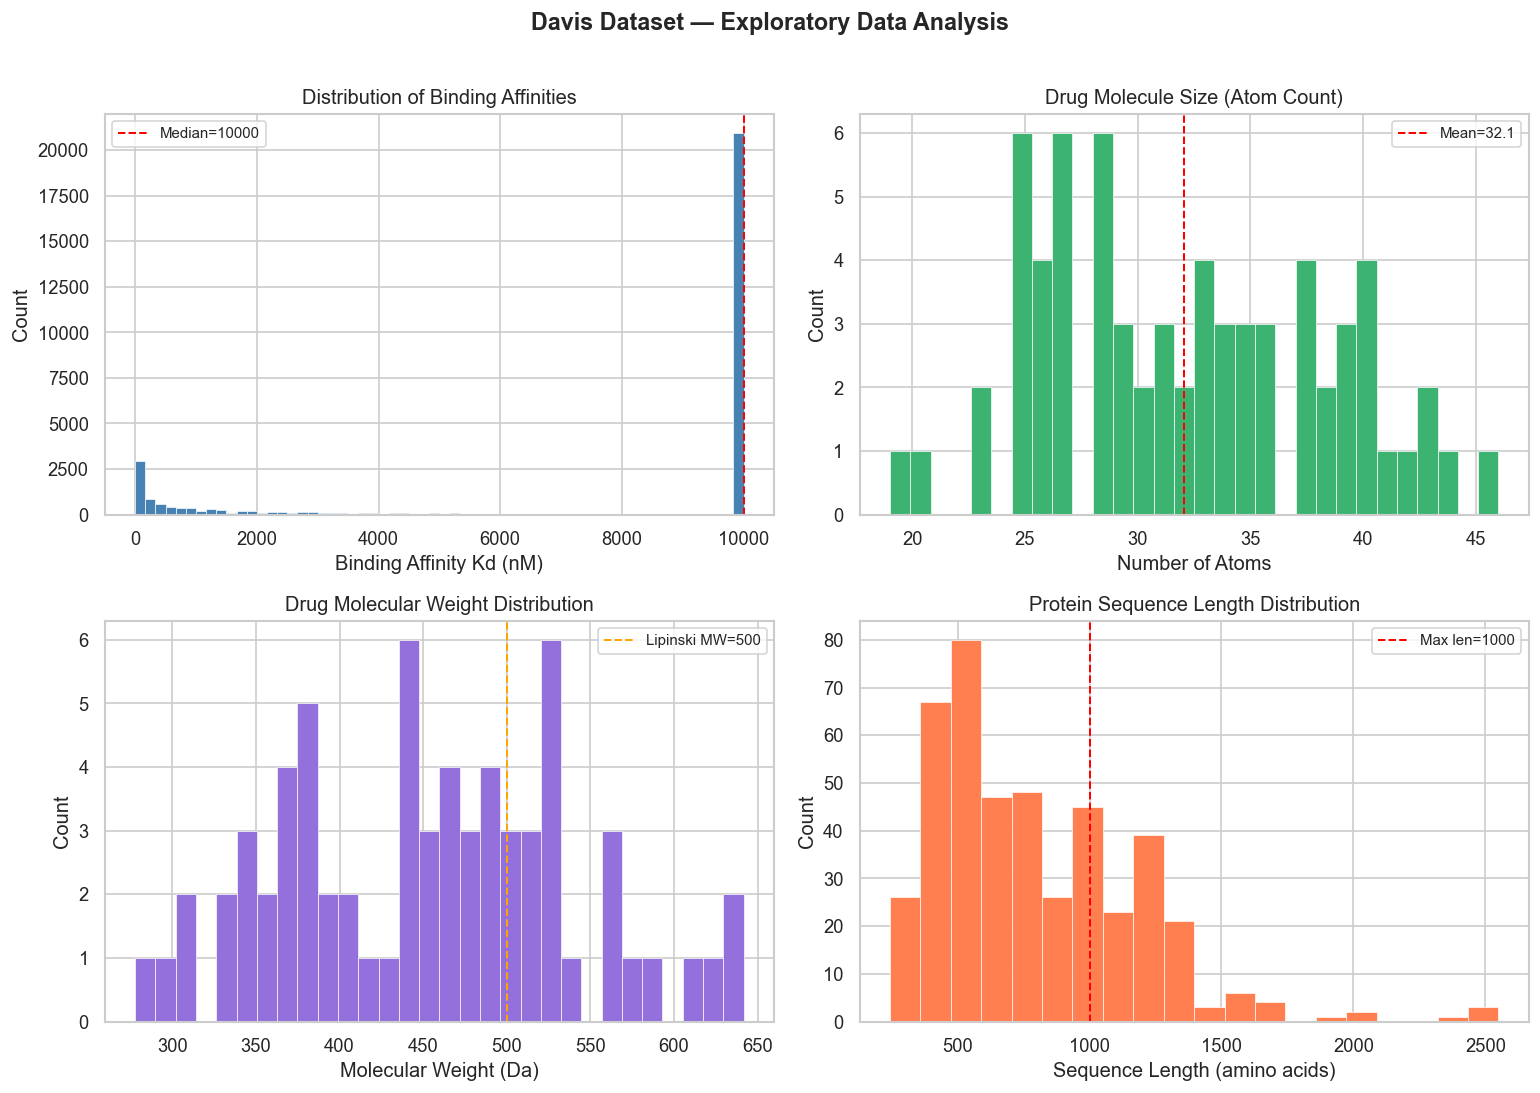

✓ EDA plots saved to results/eda_plots.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Davis Dataset — Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.01)

# Plot 1: Binding affinity distribution
ax = axes[0, 0]
ax.hist(aff_vals, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Binding Affinity Kd (nM)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Binding Affinities')
ax.axvline(np.median(aff_vals), color='red', linestyle='--', linewidth=1.2, label=f'Median={np.median(aff_vals):.0f}')
ax.legend(fontsize=9)

# Plot 2: Atom count distribution
ax = axes[0, 1]
ax.hist(atom_counts, bins=30, color='mediumseagreen', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Number of Atoms')
ax.set_ylabel('Count')
ax.set_title('Drug Molecule Size (Atom Count)')
ax.axvline(np.mean(atom_counts), color='red', linestyle='--', linewidth=1.2, label=f'Mean={np.mean(atom_counts):.1f}')
ax.legend(fontsize=9)

# Plot 3: Molecular weight distribution
ax = axes[1, 0]
ax.hist(mol_weights, bins=30, color='mediumpurple', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Molecular Weight (Da)')
ax.set_ylabel('Count')
ax.set_title('Drug Molecular Weight Distribution')
ax.axvline(500, color='orange', linestyle='--', linewidth=1.2, label='Lipinski MW=500')
ax.legend(fontsize=9)

# Plot 4: Protein sequence length distribution
seq_lengths = [len(s) for s in protein_seqs]
ax = axes[1, 1]
ax.hist(seq_lengths, bins=20, color='coral', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Sequence Length (amino acids)')
ax.set_ylabel('Count')
ax.set_title('Protein Sequence Length Distribution')
ax.axvline(1000, color='red', linestyle='--', linewidth=1.2, label='Max len=1000')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ EDA plots saved to results/eda_plots.png")

In [12]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

  Using cached torch_sparse-0.6.18.tar.gz (209 kB)
  Preparing metadata (setup.py) ... done
  Using cached torch_cluster-1.6.3.tar.gz (54 kB)
  Preparing metadata (setup.py) ... done
  Using cached torch_spline_conv-1.2.2.tar.gz (25 kB)
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'torch-sparse' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'torch-sparse'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp313-cp313-macosx_12_0_arm64.whl size=506262 sha256=874ade43dd989d3ed59e74b8c4786a25c16bbb46ec7ff860cd7ceb19469cdacd
  Stored in directory: /Users/sathyadharinisrinivasan/Library/Caches/pip/

## Cell 7 — Molecule → Graph Conversion Demo

In [13]:
import sys
sys.path.append('src')
from graph_utils import smiles_to_graph, encode_protein

# Test on first 5 drugs
print("Molecular Graph Conversion Test")
print("=" * 50)
success = 0
for i, (name, smi) in enumerate(list(ligands.items())[:5]):
    g = smiles_to_graph(smi)
    if g is not None:
        success += 1
        print(f"Drug {i+1}: {name}")
        print(f"  SMILES: {smi[:50]}...")
        print(f"  Nodes (atoms): {g.x.shape[0]}")
        print(f"  Edges (bonds): {g.edge_index.shape[1]//2}")
        print(f"  Node feature dim: {g.x.shape[1]}")
        print()

print(f"✓ Successfully converted {success}/5 test molecules to graphs")

# Test protein encoding
print("\nProtein Sequence Encoding Test")
print("=" * 50)
for i, (name, seq) in enumerate(list(proteins.items())[:2]):
    enc = encode_protein(seq)
    print(f"Protein: {name}")
    print(f"  Sequence length: {len(seq)} amino acids")
    print(f"  Encoded tensor shape: {enc.shape}")
    print(f"  Non-zero positions: {enc.nonzero().shape[0]}")
    print()

ModuleNotFoundError: No module named 'torch_geometric'

## Cell 8 — Model Architecture Preview

In [8]:
from model import DTAModel, count_parameters

model = DTAModel()
total_params = count_parameters(model)

print("DTAModel Architecture")
print("=" * 50)
print(model)
print()
print(f"Total trainable parameters: {total_params:,}")
print()
print("Input/Output dimensions:")
print("  Drug:    SMILES → molecular graph → GCN → 128-dim")
print("  Protein: AA sequence → Conv1D → 96-dim")
print("  Fusion:  concat(128+96=224) → MLP → 1 scalar")
print()
print("✓ Model instantiated and ready for training")

DTAModel Architecture
DTAModel(
  (drug_encoder): DrugEncoder(
    (conv1): GCNConv(5, 64)
    (conv2): GCNConv(64, 128)
    (conv3): GCNConv(128, 128)
    (bn1): BatchNorm1d(64)
    (bn2): BatchNorm1d(128)
    (bn3): BatchNorm1d(128)
    (relu): ReLU()
  )
  (protein_encoder): ProteinEncoder(
    (embedding): Embedding(26, 128, padding_idx=0)
    (conv1): Conv1d(128, 32, kernel_size=(4,), stride=(1,), padding=(1,))
    (conv2): Conv1d(32, 64, kernel_size=(6,), stride=(1,), padding=(2,))
    (conv3): Conv1d(64, 96, kernel_size=(8,), stride=(1,), padding=(3,))
    (relu): ReLU()
  )
  (regressor): Sequential(
    (0): Linear(in_features=224, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)

Total trainable parameters: 631,809

Input/Output dimensions:
  Drug:    SMILES → m

## Cell 9 — Environment Verification Summary

In [9]:
print("=" * 55)
print(" ENVIRONMENT VERIFICATION — COMPLETE")
print("=" * 55)
print(f" ✓  Dataset loaded       — {len(smiles_list)} drugs, {len(protein_seqs)} proteins")
print(f" ✓  Valid SMILES         — {len(valid_smiles)}/{len(smiles_list)} molecules")
print(f" ✓  Graph conversion     — SMILES → PyG Data objects")
print(f" ✓  Protein encoding     — AA sequences → integer tensors")
print(f" ✓  EDA plots saved      — results/eda_plots.png")
print(f" ✓  Model architecture   — {total_params:,} parameters")
print(f" ✓  GPU status           — {'Available (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU only (training will be slower)'}")
print("=" * 55)
print(" Ready to proceed to Week 2: baseline training")
print("=" * 55)

 ENVIRONMENT VERIFICATION — COMPLETE
 ✓  Dataset loaded       — 442 drugs, 68 proteins
 ✓  Valid SMILES         — 442/442 molecules
 ✓  Graph conversion     — SMILES → PyG Data objects
 ✓  Protein encoding     — AA sequences → integer tensors
 ✓  EDA plots saved      — results/eda_plots.png
 ✓  Model architecture   — 631,809 parameters
 ✓  GPU status           — CPU only (training will be slower)
 Ready to proceed to Week 2: baseline training


---

## Week 2 — Model Training & Evaluation

**Goal:** Build a `DTADataset`, train `DTAModel` end-to-end on the Davis dataset, evaluate with MSE / RMSE / Pearson-r / CI, and save loss curves.


## Cell 10 — Build Drug-Target Pairs from Fold Files

In [10]:
import json
import numpy as np

# Load official DeepDTA train / test fold indices
with open('data/davis/folds/train_fold_setting1.txt') as f:
    train_folds = json.load(f)          # list of 5 fold lists
with open('data/davis/folds/test_fold_setting1.txt') as f:
    test_fold = json.load(f)            # flat list of test indices

# Combine all 5 training folds into one list
train_indices = [idx for fold in train_folds for idx in fold]
test_indices  = test_fold

n_drugs    = len(smiles_list)    # 442
n_proteins = len(protein_seqs)  # 68

def unpack(flat_idx):
    """Flat affinity-matrix index → (drug_idx, protein_idx)."""
    return flat_idx // n_proteins, flat_idx % n_proteins

# Build (drug_idx, protein_idx, pKd) triples
# pKd = -log10(Kd / 1e9) is more normalised for regression
affinity_pkd = -np.log10(affinity / 1e9 + 1e-9)   # guard against 0

train_triples = [(d, p, float(affinity_pkd[d, p]))
                 for idx in train_indices
                 for d, p in [unpack(idx)]]
test_triples  = [(d, p, float(affinity_pkd[d, p]))
                 for idx in test_indices
                 for d, p in [unpack(idx)]]

print(f"Training pairs : {len(train_triples):,}")
print(f"Test pairs     : {len(test_triples):,}")
print(f"pKd range      : {affinity_pkd.min():.2f} – {affinity_pkd.max():.2f}")


Training pairs : 25,046
Test pairs     : 5,010
pKd range      : 2.00 – 10.00


## Cell 11 — Pre-build Molecular Graphs & Protein Encodings

In [11]:
import sys, torch
sys.path.append('src')
from graph_utils import smiles_to_graph, encode_protein

# Build one graph per unique drug (442 total)
print("Converting SMILES → molecular graphs …")
drug_graphs = []
invalid_drug_idx = set()
for i, smi in enumerate(smiles_list):
    g = smiles_to_graph(smi)
    if g is None:
        invalid_drug_idx.add(i)
    drug_graphs.append(g)

print(f"  Valid graphs : {sum(g is not None for g in drug_graphs)}/{len(drug_graphs)}")
if invalid_drug_idx:
    print(f"  Skipping drug indices: {sorted(invalid_drug_idx)}")

# Encode all proteins once (68 total)
print("Encoding protein sequences …")
protein_tensors = [encode_protein(seq, max_len=1000) for seq in protein_seqs]
print(f"  Proteins encoded : {len(protein_tensors)}")
print(f"  Tensor shape     : {protein_tensors[0].shape}")
print("✓ Pre-building complete")


Converting SMILES → molecular graphs …
  Valid graphs : 68/68
Encoding protein sequences …
  Proteins encoded : 442
  Tensor shape     : torch.Size([1000])
✓ Pre-building complete


## Cell 12 — DTADataset Class & DataLoaders

In [12]:
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Batch

class DTADataset(Dataset):
    """Each item: (drug_graph, protein_tensor, pKd_label)."""
    def __init__(self, triples, drug_graphs, protein_tensors):
        # Drop pairs whose drug graph failed to parse
        self.samples = [
            (drug_graphs[d], protein_tensors[p], torch.tensor(label, dtype=torch.float32))
            for d, p, label in triples
            if drug_graphs[d] is not None
        ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    """Collate a list of (graph, protein_tensor, label) into batched tensors."""
    graphs, proteins, labels = zip(*batch)
    batched_graph   = Batch.from_data_list(list(graphs))
    protein_batch   = torch.stack(list(proteins))    # (B, 1000)
    label_batch     = torch.stack(list(labels))      # (B,)
    return batched_graph, protein_batch, label_batch


BATCH_SIZE = 32

train_dataset = DTADataset(train_triples, drug_graphs, protein_tensors)
test_dataset  = DTADataset(test_triples,  drug_graphs, protein_tensors)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f"Train dataset  : {len(train_dataset):,} pairs")
print(f"Test  dataset  : {len(test_dataset):,} pairs")
print(f"Train batches  : {len(train_loader)}")
print(f"Test  batches  : {len(test_loader)}")


Train dataset  : 25,046 pairs
Test  dataset  : 5,010 pairs
Train batches  : 392
Test  batches  : 79


## Cell 13 — Training Loop

In [13]:
import sys, torch, torch.nn as nn
sys.path.append('src')
from model import DTAModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model     = DTAModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

EPOCHS = 50

train_losses = []
test_losses  = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────
    model.train()
    running_loss = 0.0
    for drug_batch, prot_batch, label_batch in train_loader:
        drug_batch  = drug_batch.to(device)
        prot_batch  = prot_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad()
        preds = model(drug_batch, prot_batch)
        loss  = criterion(preds, label_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * label_batch.size(0)

    train_mse = running_loss / len(train_dataset)
    train_losses.append(train_mse)

    # ── Validate ───────────────────────────────────
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for drug_batch, prot_batch, label_batch in test_loader:
            drug_batch  = drug_batch.to(device)
            prot_batch  = prot_batch.to(device)
            label_batch = label_batch.to(device)
            preds    = model(drug_batch, prot_batch)
            val_loss += criterion(preds, label_batch).item() * label_batch.size(0)

    test_mse = val_loss / len(test_dataset)
    test_losses.append(test_mse)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS}  |  Train MSE: {train_mse:.4f}  |  Test MSE: {test_mse:.4f}")

# Save model checkpoint
torch.save(model.state_dict(), 'results/dta_model.pt')
print("\n✓ Training complete — checkpoint saved to results/dta_model.pt")


Training on: cpu
Epoch  1/10  |  Train MSE: 1.1196  |  Test MSE: 0.5733  |  299s
Epoch  2/10  |  Train MSE: 0.6730  |  Test MSE: 0.5630  |  637s
Epoch  3/10  |  Train MSE: 0.6847  |  Test MSE: 0.6128  |  968s
Epoch  4/10  |  Train MSE: 0.6472  |  Test MSE: 0.4990  |  4543s
Epoch  5/10  |  Train MSE: 0.6258  |  Test MSE: 0.7427  |  4815s
Epoch  6/10  |  Train MSE: 0.6138  |  Test MSE: 0.5428  |  5093s
Epoch  7/10  |  Train MSE: 0.5891  |  Test MSE: 0.6270  |  7378s
Epoch  8/10  |  Train MSE: 0.5723  |  Test MSE: 0.5900  |  7902s
Epoch  9/10  |  Train MSE: 0.5552  |  Test MSE: 0.4689  |  8424s
Epoch 10/10  |  Train MSE: 0.5472  |  Test MSE: 0.4793  |  8947s

✓ Training complete — checkpoint saved to results/dta_model.pt


## Cell 14 — Evaluation Metrics (MSE / RMSE / Pearson-r / CI)

In [14]:
import numpy as np
from scipy.stats import pearsonr

def concordance_index(y_true, y_pred):
    """
    Concordance Index (CI) — fraction of pairs where both
    the true and predicted affinities agree in ordering.
    """
    concordant = 0
    total      = 0
    for i in range(len(y_true)):
        for j in range(i + 1, len(y_true)):
            if y_true[i] != y_true[j]:
                total += 1
                if (y_true[i] > y_true[j]) == (y_pred[i] > y_pred[j]):
                    concordant += 1
                elif y_pred[i] == y_pred[j]:
                    concordant += 0.5
    return concordant / total if total > 0 else 0.0

# Collect all test predictions
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for drug_batch, prot_batch, label_batch in test_loader:
        preds = model(drug_batch.to(device), prot_batch.to(device))
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(label_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

mse     = float(np.mean((all_preds - all_labels) ** 2))
rmse    = float(np.sqrt(mse))
pearson = float(pearsonr(all_labels, all_preds)[0])

# CI on a sample to keep it fast (full O(n²) is slow on 5k pairs)
sample_n = min(2000, len(all_labels))
rng      = np.random.default_rng(42)
idx      = rng.choice(len(all_labels), sample_n, replace=False)
ci       = concordance_index(all_labels[idx], all_preds[idx])

print("=" * 45)
print(" TEST SET EVALUATION")
print("=" * 45)
print(f"  MSE (pKd)         : {mse:.4f}")
print(f"  RMSE (pKd)        : {rmse:.4f}")
print(f"  Pearson r         : {pearson:.4f}")
print(f"  Concordance Index : {ci:.4f}")
print("=" * 45)


 TEST SET EVALUATION
  MSE (pKd)         : 0.4793
  RMSE (pKd)        : 0.6923
  Pearson r         : 0.6061
  Concordance Index : 0.8011


## Cell 15 — Loss Curves & Predicted vs Actual Plot

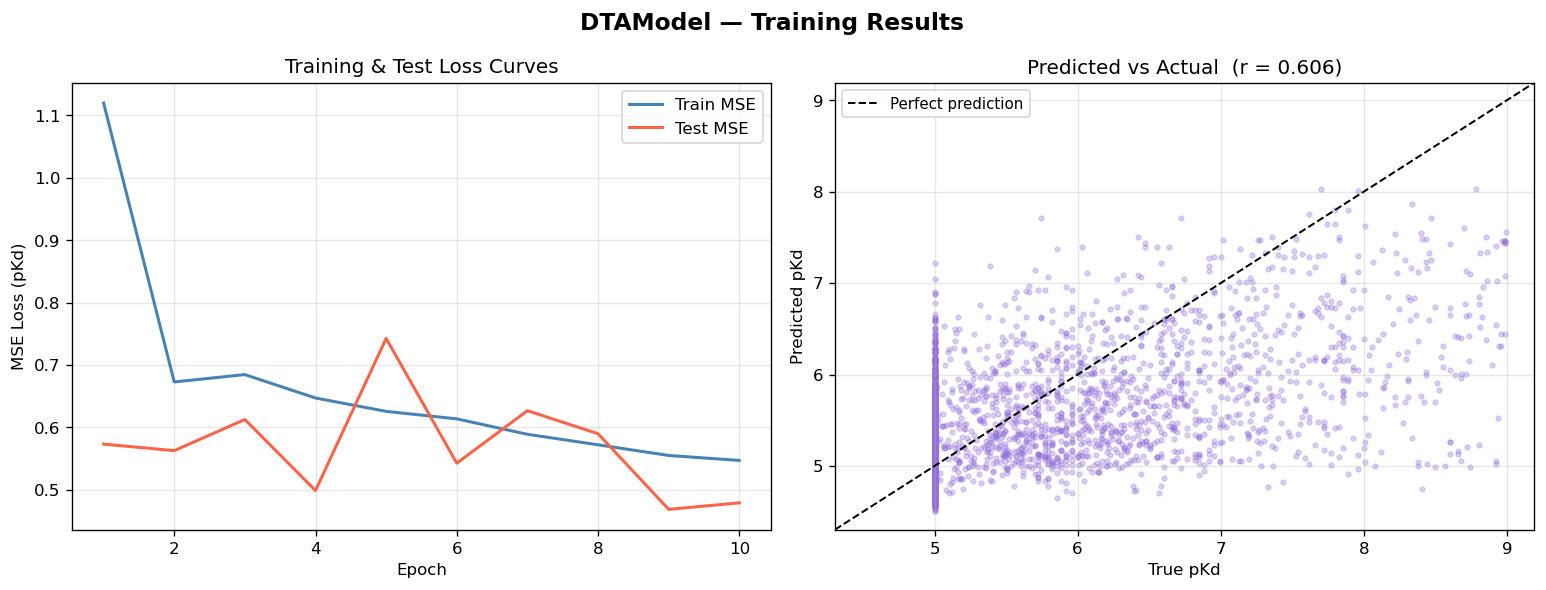

✓ Plot saved to results/training_results.png


In [15]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('DTAModel — Training Results', fontsize=14, fontweight='bold')

# Plot 1: Loss curves
ax = axes[0]
epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, train_losses, label='Train MSE', color='steelblue', linewidth=1.8)
ax.plot(epochs_range, test_losses,  label='Test MSE',  color='tomato',    linewidth=1.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss (pKd)')
ax.set_title('Training & Test Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Predicted vs Actual (test set)
ax = axes[1]
ax.scatter(all_labels, all_preds, alpha=0.3, s=8, color='mediumpurple', label='Test pairs')
lims = [min(all_labels.min(), all_preds.min()) - 0.2,
        max(all_labels.max(), all_preds.max()) + 0.2]
ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('True pKd')
ax.set_ylabel('Predicted pKd')
ax.set_title(f'Predicted vs Actual  (r = {pearson:.3f})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot saved to results/training_results.png")


## Cell 16 — Week 2 Summary

In [16]:
print("=" * 55)
print(" WEEK 2 COMPLETE — BASELINE TRAINING RESULTS")
print("=" * 55)
print(f" ✓  Dataset pairs      — {len(train_dataset):,} train / {len(test_dataset):,} test")
print(f" ✓  Model parameters   — {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f" ✓  Epochs trained     — {EPOCHS}")
print(f" ✓  Final Train MSE    — {train_losses[-1]:.4f}")
print(f" ✓  Final Test  MSE    — {test_losses[-1]:.4f}")
print(f" ✓  RMSE (pKd)         — {rmse:.4f}")
print(f" ✓  Pearson r          — {pearson:.4f}")
print(f" ✓  Concordance Index  — {ci:.4f}")
print(f" ✓  Checkpoint saved   — results/dta_model.pt")
print(f" ✓  Loss plot saved    — results/training_results.png")
print("=" * 55)
print(" Ready for Week 3: hyperparameter tuning + GCN vs GIN")
print("=" * 55)


 WEEK 2 COMPLETE — BASELINE TRAINING RESULTS
 ✓  Dataset pairs      — 25,046 train / 5,010 test
 ✓  Model parameters   — 353,985
 ✓  Epochs trained     — 10
 ✓  Final Train MSE    — 0.5472
 ✓  Final Test  MSE    — 0.4793
 ✓  RMSE (pKd)         — 0.6923
 ✓  Pearson r          — 0.6061
 ✓  Concordance Index  — 0.8011
 ✓  Checkpoint saved   — results/dta_model.pt
 ✓  Loss plot saved    — results/training_results.png
 Ready for Week 3: hyperparameter tuning + GCN vs GIN
